# 🧹 Data Preprocessing & EDA

"Garbage in, garbage out." No algorithm — not even the fanciest gradient-boosted ensemble — can produce a good model from a dirty dataset. This notebook builds the full preprocessing toolkit: missing values, duplicates, categorical encoding, outlier treatment, and feature scaling, applied to a deliberately messy synthetic dataset that mimics real-world data problems.

📖 Full mathematical explanation (missingness types, encoding math, scaling formulas): [README.md](README.md)


## 1. Building a Deliberately Messy Dataset

To practice preprocessing, we need problems to fix. This synthetic dataset has: missing values, duplicate rows, a categorical column, mixed/incorrect dtypes, and injected outliers — the same issues you'll meet in real tabular data.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import (
    LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler
)


In [2]:
sns.set_theme(style="whitegrid")
np.random.seed(42)


In [3]:
n = 200
df = pd.DataFrame({
    "age": np.random.normal(35, 10, n).round(1),
    "income": np.random.normal(50000, 15000, n).round(0),
    "years_experience": np.random.normal(8, 4, n).round(1).clip(0, None),
    "city": np.random.choice(["Dhaka", "Chittagong", "Khulna", "Rajshahi"], n),
})


In [4]:
# Inject missing values (simulating real-world sensor/survey gaps)
missing_idx = np.random.choice(df.index, size=20, replace=False)
df.loc[missing_idx[:10], "income"] = np.nan
df.loc[missing_idx[10:], "years_experience"] = np.nan


In [5]:
# Inject outliers (data entry errors, e.g. an extra zero typed by mistake)
df.loc[df.sample(3, random_state=1).index, "income"] *= 8


In [6]:
# Inject exact duplicate rows (common in scraped/merged datasets)
df = pd.concat([df, df.iloc[[0, 5, 10]]], ignore_index=True)


In [7]:
print(f"Shape: {df.shape}")
df.head(10)


Shape: (203, 4)


,age,income,years_experience,city
0,40.0,55367.0,1.6,Khulna
1,33.6,58412.0,5.6,Rajshahi
2,41.5,66246.0,8.0,Rajshahi
3,50.2,65807.0,8.2,Dhaka
4,32.7,29335.0,6.2,Chittagong
5,32.7,35933.0,10.5,Khulna
6,50.8,57726.0,3.7,Khulna
7,42.7,57707.0,7.4,Khulna
8,30.3,57726.0,8.5,Khulna
9,40.4,107791.0,10.1,Rajshahi


## 2. First-Look EDA — Know Your Damage Before Fixing It

Before writing a single cleaning line, quantify *what* is broken: how much is missing, where, and how it's distributed. `.info()` + a missingness heatmap answer this in seconds.


In [8]:
df.info()
print("\nMissing value counts:\n", df.isna().sum())


<class 'pandas.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               203 non-null    float64
 1   income            193 non-null    float64
 2   years_experience  193 non-null    float64
 3   city              203 non-null    str    
dtypes: float64(3), str(1)
memory usage: 6.5 KB

Missing value counts:
 age                  0
income              10
years_experience    10
city                 0
dtype: int64


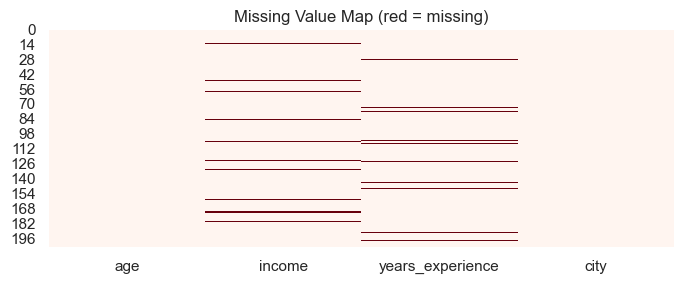

In [9]:
fig, ax = plt.subplots(figsize=(7, 3))
sns.heatmap(df.isna(), cbar=False, cmap="Reds", ax=ax)
ax.set_title("Missing Value Map (red = missing)")
plt.tight_layout()
plt.show()


## 3. Duplicate Detection & Removal

Duplicate rows silently bias any statistic (mean, correlation) and, worse, can leak identical samples across a train/test split — one of the most common causes of falsely inflated model accuracy.


In [10]:
print("Duplicate rows found:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)


Duplicate rows found: 3
Shape after dropping duplicates: (200, 4)


## 4. Handling Missing Data — Three Strategies Compared

We compare **mean imputation** (fast, biases variance downward), **median imputation** (robust to the outliers we injected), and **KNN imputation** (uses similar rows to estimate a value — usually the most accurate, at higher compute cost). Math for all three is in the README.


In [11]:
df_mean = df.copy()
df_mean["income"] = df_mean["income"].fillna(df_mean["income"].mean())


In [12]:
df_median = df.copy()
df_median["income"] = df_median["income"].fillna(df_median["income"].median())


In [13]:
# KNN imputation needs purely numeric columns; run it on the numeric subset
numeric_cols = ["age", "income", "years_experience"]
knn_imputer = KNNImputer(n_neighbors=5)
df_knn_values = knn_imputer.fit_transform(df[numeric_cols])
df_knn = df.copy()
df_knn[numeric_cols] = df_knn_values


In [14]:
comparison = pd.DataFrame({
    "mean_imputation": [df_mean["income"].mean()],
    "median_imputation": [df_median["income"].mean()],
    "knn_imputation": [df_knn["income"].mean()],
}, index=["resulting mean income"])
print(comparison)
print("\n-> Mean imputation is pulled upward by the outlier-inflated incomes we injected;")
print("   median/KNN are more robust. We proceed with the median-imputed version for years_experience,")
print("   and will re-derive income cleanly after outlier treatment below.")
df["years_experience"] = df["years_experience"].fillna(df["years_experience"].median())


                       mean_imputation  median_imputation  knn_imputation
resulting mean income     58107.689474           57788.88       57805.765

-> Mean imputation is pulled upward by the outlier-inflated incomes we injected;
   median/KNN are more robust. We proceed with the median-imputed version for years_experience,
   and will re-derive income cleanly after outlier treatment below.


## 5. Outlier Detection & Treatment — Z-Score Method

Topic 02 used the **IQR rule** visually via boxplots. Here we apply the complementary **Z-score rule** programmatically, then treat outliers with **capping (winsorization)** instead of deleting rows — preserving sample size while limiting the outlier's influence.


In [15]:
def zscore_outliers(series, threshold=3):
    z = (series - series.mean()) / series.std()
    return z.abs() > threshold


In [16]:
income_valid = df["income"].dropna()
outlier_mask = zscore_outliers(income_valid)
print(f"Outliers detected (|z| > 3): {outlier_mask.sum()} out of {len(income_valid)}")
print("Outlier values:", income_valid[outlier_mask].tolist())


Outliers detected (|z| > 3): 3 out of 190
Outlier values: [657272.0, 304896.0, 453256.0]


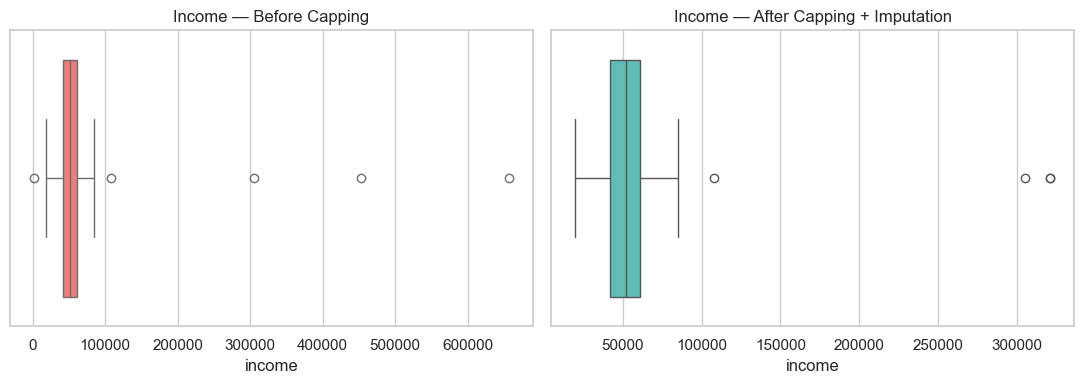

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(x=df["income"], ax=axes[0], color="#ff6b6b")
axes[0].set_title("Income — Before Capping")
# Winsorize: cap values beyond the 1st/99th percentile instead of dropping them
lower_cap, upper_cap = df["income"].quantile([0.01, 0.99])
df["income"] = df["income"].clip(lower=lower_cap, upper=upper_cap)
df["income"] = df["income"].fillna(df["income"].median())   # impute remaining NaNs post-capping
sns.boxplot(x=df["income"], ax=axes[1], color="#4ecdc4")
axes[1].set_title("Income — After Capping + Imputation")
plt.tight_layout()
plt.show()


## 6. Encoding Categorical Variables

Models need numbers, not strings. Three encodings, each with a different assumption:

- **Label Encoding** — assigns an arbitrary integer per category. Only valid when categories have a true **order** (ordinal); using it on unordered categories tricks the model into thinking `Dhaka < Khulna`.
- **One-Hot Encoding** — creates one binary column per category. Safe default for **unordered (nominal)** categories, at the cost of extra dimensions.
- **`pd.get_dummies`** — Pandas' convenient shortcut for one-hot encoding directly on a DataFrame.


In [18]:
# Label Encoding — shown for completeness, but city has NO natural order, so this is a bad fit for it
label_enc = LabelEncoder()
city_label_encoded = label_enc.fit_transform(df["city"])
print("Label-encoded city (arbitrary order!):", dict(zip(label_enc.classes_, range(len(label_enc.classes_)))))


Label-encoded city (arbitrary order!): {'Chittagong': 0, 'Dhaka': 1, 'Khulna': 2, 'Rajshahi': 3}


In [19]:
# One-Hot Encoding — the correct choice for an unordered category like city
city_onehot = pd.get_dummies(df["city"], prefix="city")
df_encoded = pd.concat([df.drop(columns=["city"]), city_onehot], axis=1)
df_encoded.head()


,age,income,years_experience,city_Chittagong,city_Dhaka,city_Khulna,city_Rajshahi
0,40.0,55367.0,1.6,False,False,True,False
1,33.6,58412.0,5.6,False,False,False,True
2,41.5,66246.0,8.0,False,False,False,True
3,50.2,65807.0,8.2,False,True,False,False
4,32.7,29335.0,6.2,True,False,False,False


## 7. Feature Scaling — Three Scalers Compared

Different algorithms need different scaling assumptions (formulas in README):

- **StandardScaler** — zero mean, unit variance. Best default for distance-based (KNN, SVM) and gradient-based (Logistic Regression, Neural Nets) models.
- **MinMaxScaler** — squashes to a fixed `[0, 1]` range. Useful when a bounded range is required (e.g. some neural net activations).
- **RobustScaler** — uses median/IQR instead of mean/std, so it resists outliers even better than StandardScaler.


In [20]:
scale_cols = ["age", "income", "years_experience"]
standard_scaled = StandardScaler().fit_transform(df_encoded[scale_cols])
minmax_scaled = MinMaxScaler().fit_transform(df_encoded[scale_cols])
robust_scaled = RobustScaler().fit_transform(df_encoded[scale_cols])


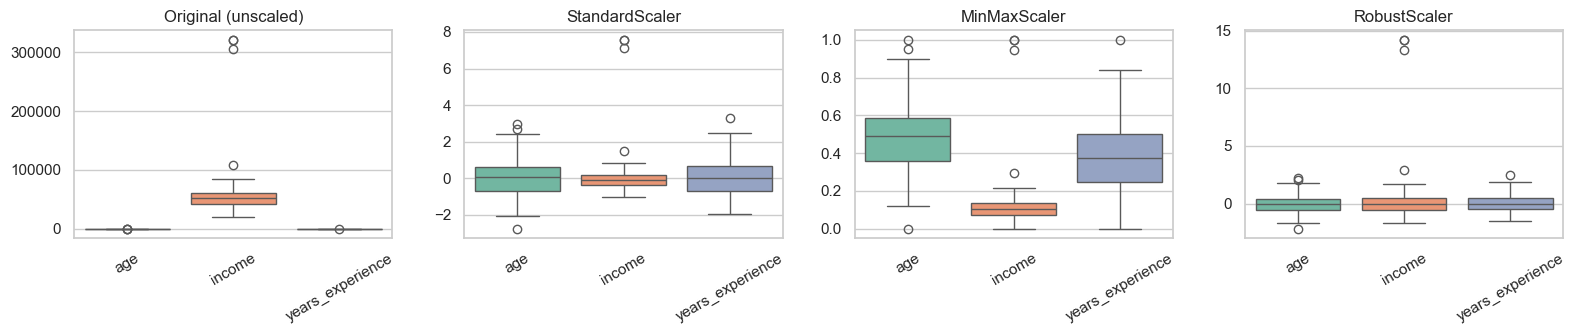

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
sns.boxplot(data=df_encoded[scale_cols], ax=axes[0], palette="Set2")
axes[0].set_title("Original (unscaled)")
axes[0].tick_params(axis="x", rotation=30)
for ax, data, title in zip(
    axes[1:],
    [standard_scaled, minmax_scaled, robust_scaled],
    ["StandardScaler", "MinMaxScaler", "RobustScaler"],
):
    sns.boxplot(data=pd.DataFrame(data, columns=scale_cols), ax=ax, palette="Set2")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


## 8. Categorical Missing Value Imputation — Mode

Numeric columns get mean/median/KNN imputation. Categorical columns can't be averaged — the standard fallback is **mode imputation** (fill with the most frequent category), or a dedicated `"Missing"` category when the fact that a value is missing is itself informative.


In [22]:
df_cat_dirty = df.copy()
missing_city_idx = df_cat_dirty.sample(5, random_state=2).index
df_cat_dirty.loc[missing_city_idx, "city"] = np.nan


In [23]:
print("City missing count:", df_cat_dirty["city"].isna().sum())
mode_city = df_cat_dirty["city"].mode()[0]
print("Mode city:", mode_city)


City missing count: 5
Mode city: Khulna


In [24]:
df_cat_dirty["city"] = df_cat_dirty["city"].fillna(mode_city)
print("Remaining missing after mode imputation:", df_cat_dirty["city"].isna().sum())


Remaining missing after mode imputation: 0


## 9. Cardinality Check & Rare Category Grouping

A categorical column with hundreds of unique values ("high cardinality") explodes one-hot encoding into hundreds of columns and gives the model too few examples per category to learn from. The standard fix: group categories below a frequency threshold into a single `"Other"` bucket.


In [25]:
np.random.seed(3)
zip_codes = np.random.choice(
    [f"ZIP{i:03d}" for i in range(60)],
    size=200,
    p=[0.15, 0.12, 0.10] + [0.63 / 57] * 57,   # 3 common zips + 57 rare ones
)
zip_series = pd.Series(zip_codes)


In [26]:
print("Unique categories:", zip_series.nunique())
print("\nTop 5 by frequency:\n", zip_series.value_counts().head())


Unique categories: 51

Top 5 by frequency:
 ZIP001    28
ZIP000    26
ZIP002    23
ZIP032     7
ZIP035     6
Name: count, dtype: int64


In [27]:
# Group anything below 3% frequency into "Other"
freq = zip_series.value_counts(normalize=True)
rare_categories = freq[freq < 0.03].index
zip_grouped = zip_series.where(~zip_series.isin(rare_categories), "Other")


In [28]:
print("\nCategories after grouping rare ones:", zip_grouped.nunique())
print(zip_grouped.value_counts().head())



Categories after grouping rare ones: 7
Other     104
ZIP001     28
ZIP000     26
ZIP002     23
ZIP032      7
Name: count, dtype: int64


## 10. Class Imbalance Detection & Class Weights

Many real targets are imbalanced (fraud detection, rare disease diagnosis). A model trained naively on an imbalanced target can reach high accuracy by just always predicting the majority class — useless in practice. The first defense is *detecting* the imbalance, then computing **class weights** to make the training loss penalize minority-class mistakes more heavily.


In [29]:
from sklearn.utils.class_weight import compute_class_weight
df["high_earner"] = (df["income"] > df["income"].quantile(0.85)).astype(int)   # deliberately imbalanced ~15/85 split


In [30]:
class_counts = df["high_earner"].value_counts()
print("Class distribution:\n", class_counts)
print(f"\nImbalance ratio: {class_counts[0] / class_counts[1]:.1f} : 1")


Class distribution:
 high_earner
0    170
1     30
Name: count, dtype: int64

Imbalance ratio: 5.7 : 1


In [31]:
weights = compute_class_weight(class_weight="balanced", classes=np.array([0, 1]), y=df["high_earner"])
print("\nBalanced class weights:", dict(zip([0, 1], weights)))
print("-> The minority class (1) gets a higher weight, so misclassifying it costs the model more during training.")



Balanced class weights: {0: np.float64(0.5882352941176471), 1: np.float64(3.3333333333333335)}
-> The minority class (1) gets a higher weight, so misclassifying it costs the model more during training.


## 11. Correlation-Based Redundant Feature Removal

Two near-perfectly correlated features carry almost the same information — keeping both adds noise and, for linear models, multicollinearity (unstable coefficients). A simple automated rule: for any pair with `|r| > threshold`, drop one.


In [32]:
df_redundant = df.copy()
df_redundant["income_duplicate"] = df_redundant["income"] * 1.02 + np.random.normal(0, 50, len(df_redundant))   # near-duplicate of income


In [33]:
numeric_cols = ["age", "income", "years_experience", "income_duplicate"]
corr = df_redundant[numeric_cols].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))


In [34]:
to_drop = [col for col in upper.columns if (upper[col] > 0.95).any()]
print("Correlation matrix:\n", corr.round(2))
print("\nColumns flagged as redundant (|r| > 0.95):", to_drop)


Correlation matrix:
                    age  income  years_experience  income_duplicate
age               1.00    0.12              0.12              0.12
income            0.12    1.00              0.04              1.00
years_experience  0.12    0.04              1.00              0.04
income_duplicate  0.12    1.00              0.04              1.00

Columns flagged as redundant (|r| > 0.95): ['income_duplicate']


In [35]:
df_reduced = df_redundant.drop(columns=to_drop)
print("Shape before:", df_redundant.shape, "-> after:", df_reduced.shape)


Shape before: (200, 6) -> after: (200, 5)


## 12. Train-Test Split with Stratification

A plain random split can accidentally produce a test set with a very different class balance than the training set — especially damaging for the imbalanced target from section 10. **Stratified** splitting preserves the class proportions in both splits.


In [36]:
from sklearn.model_selection import train_test_split
X = df[["age", "years_experience"]]
y = df["high_earner"]


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [38]:
print("Full dataset positive rate:  ", y.mean().round(3))
print("Train split positive rate:   ", y_train.mean().round(3))
print("Test split positive rate:    ", y_test.mean().round(3))
print("-> Stratification keeps all three close together, unlike a plain random split on an imbalanced target.")


Full dataset positive rate:   0.15
Train split positive rate:    0.15
Test split positive rate:     0.15
-> Stratification keeps all three close together, unlike a plain random split on an imbalanced target.


## 13. Removing Near-Zero-Variance Features

A feature that's (almost) constant across every row carries essentially no information for distinguishing outcomes, yet still costs memory/compute and can destabilize some models. `VarianceThreshold` is the cheapest possible automated filter — pure computation, no relationship to the target required.


In [39]:
from sklearn.feature_selection import VarianceThreshold
df_nzv = df[["age", "income", "years_experience"]].copy()
df_nzv["near_constant"] = 1   # simulate a broken/near-constant sensor column
df_nzv.loc[df_nzv.sample(2, random_state=4).index, "near_constant"] = 2   # a couple of rare exceptions


In [40]:
selector = VarianceThreshold(threshold=0.05)
selector.fit(df_nzv)
kept = df_nzv.columns[selector.get_support()]
print("Columns kept:", list(kept))
print("Columns dropped (near-zero variance):", list(set(df_nzv.columns) - set(kept)))


Columns kept: ['age', 'income', 'years_experience']
Columns dropped (near-zero variance): ['near_constant']


## 14. Full Preprocessing Pipeline — `ColumnTransformer` + `Pipeline`

Chaining every step above by hand (as this notebook does for teaching clarity) is error-prone in a real project — a stray line skipped on the test set is a classic leakage bug. `ColumnTransformer` applies different preprocessing to different column types in one object; `Pipeline` chains steps so `fit`/`transform` always happens in the same order, on the correct split, every time.


In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


In [42]:
numeric_features = ["age", "income", "years_experience"]
categorical_features = ["city"]


In [43]:
numeric_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore")),
])


In [44]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])


In [45]:
X_transformed = preprocessor.fit_transform(df[numeric_features + categorical_features])
print("Input shape :", df[numeric_features + categorical_features].shape)
print("Output shape:", X_transformed.shape)
print("-> One .fit_transform() call did imputation + scaling + encoding together, consistently.")


Input shape : (200, 4)
Output shape: (200, 7)
-> One .fit_transform() call did imputation + scaling + encoding together, consistently.


## 15. Final Clean Dataset

A quick before/after summary — this is the dataset now ready to feed into any Classical ML algorithm from the next repo in this series.


In [46]:
df_final = df_encoded.copy()
df_final[scale_cols] = standard_scaled


In [47]:
print("Final shape:", df_final.shape)
print("Remaining missing values:", df_final.isna().sum().sum())
print("Remaining duplicate rows:", df_final.duplicated().sum())
df_final.head()


Final shape: (200, 7)
Remaining missing values: 0
Remaining duplicate rows: 0


,age,income,years_experience,city_Chittagong,city_Dhaka,city_Khulna,city_Rajshahi
0,0.582298,-0.005085,-1.577384,False,False,True,False
1,-0.106939,0.081719,-0.538863,False,False,False,True
2,0.743838,0.305045,0.084250,False,False,False,True
3,1.680770,0.292530,0.136176,False,True,False,False
4,-0.203863,-0.747185,-0.383085,True,False,False,False


## ✅ Key Takeaways

- Always run a missingness + duplicate audit (`.info()`, `.isna().sum()`, `.duplicated().sum()`) **before** any cleaning decision — you need to know the shape of the damage first.
- Mean imputation is fragile to outliers; median and KNN imputation are more robust — choose based on how the feature is distributed (check with topic 02's histogram/boxplot tools).
- Capping (winsorizing) outliers preserves sample size, unlike dropping rows outright — usually preferable unless you're certain the value is a data-entry error.
- Never Label-Encode a nominal (unordered) category — it silently invents a false numeric order that misleads distance-based and linear models.
- Scaler choice matters: StandardScaler for most algorithms, RobustScaler when outliers remain a concern, MinMaxScaler when a bounded range is explicitly required.
- High-cardinality categoricals need rare-category grouping before encoding; imbalanced targets need detection (and class weights) before training, not after a suspiciously high accuracy shows up.
- `ColumnTransformer` + `Pipeline` isn't just convenience — it's the standard defense against leakage bugs from hand-chaining preprocessing steps in the wrong order or on the wrong split.

**Next up:** [04_Feature_Engineering](../04_Feature_Engineering/) — going beyond cleaning to actively creating better features.
